<a href="https://colab.research.google.com/github/Fahrisetiadarma/DataAnalytics/blob/main/Superstore_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/New/orders.csv')
df2 = pd.read_csv('/content/drive/MyDrive/New/order_detail.csv')
df3 = pd.read_csv('/content/drive/MyDrive/New/product.csv')

# Orders

In [ ]:
df1

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520
1,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045
2,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335
3,CA-2011-115812,2011-06-09,2011-06-14,Standard Class,BH-11710
4,CA-2014-114412,2014-04-16,2014-04-21,Standard Class,AA-10480
...,...,...,...,...,...
5004,CA-2013-125794,2013-09-30,2013-10-04,Standard Class,ML-17410
5005,CA-2014-163629,2014-11-18,2014-11-22,Standard Class,RA-19885
5006,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400
5007,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order ID     5009 non-null   object
 1   Order Date   5009 non-null   object
 2   Ship Date    5009 non-null   object
 3   Ship Mode    5009 non-null   object
 4   Customer ID  5009 non-null   object
dtypes: object(5)
memory usage: 195.8+ KB


In [ ]:
df1['Order Date'] = pd.to_datetime(df1['Order Date'])

In [ ]:
df1.dtypes

,0
Order ID,object
Order Date,datetime64[ns]
Ship Date,object
Ship Mode,object
Customer ID,object


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order ID     5009 non-null   object        
 1   Order Date   5009 non-null   datetime64[ns]
 2   Ship Date    5009 non-null   object        
 3   Ship Mode    5009 non-null   object        
 4   Customer ID  5009 non-null   object        
dtypes: datetime64[ns](1), object(4)
memory usage: 195.8+ KB


In [ ]:
df1.describe(include=object)

,Order ID,Ship Date,Ship Mode,Customer ID
count,5009,5009,5009,5009
unique,5009,1334,4,793
top,CA-2014-119914,2014-11-17,Standard Class,EP-13915
freq,1,17,2994,17


In [ ]:
df1.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0


In [ ]:
print(f"Total duplicated rows : {df2.duplicated().sum()}")

Total duplicated rows : 1


# Orders Detail

In [ ]:
df2

,Order ID,Product ID,Sales,Quantity,Discount,Profit
0,CA-2013-152156,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2013-152156,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2013-138688,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2012-108966,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2012-108966,OFF-ST-10000760,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...
9989,CA-2011-110422,FUR-FU-10001889,25.2480,3,0.20,4.1028
9990,CA-2014-121258,FUR-FU-10000747,91.9600,2,0.00,15.6332
9991,CA-2014-121258,TEC-PH-10003645,258.5760,2,0.20,19.3932
9992,CA-2014-121258,OFF-PA-10004041,29.6000,4,0.00,13.3200


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order ID    9994 non-null   object 
 1   Product ID  9994 non-null   object 
 2   Sales       9994 non-null   float64
 3   Quantity    9994 non-null   int64  
 4   Discount    9994 non-null   float64
 5   Profit      9994 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 468.6+ KB


In [ ]:
df2.dtypes

,0
Order ID,object
Product ID,object
Sales,float64
Quantity,int64
Discount,float64
Profit,float64


In [ ]:
df2.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


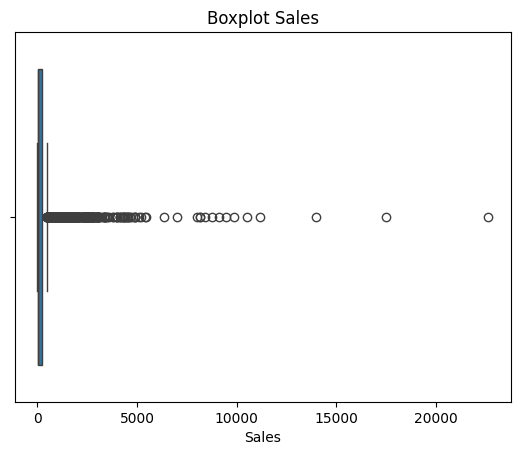

In [ ]:
sns.boxplot(x=df2["Sales"])
plt.title("Boxplot Sales")
plt.show()

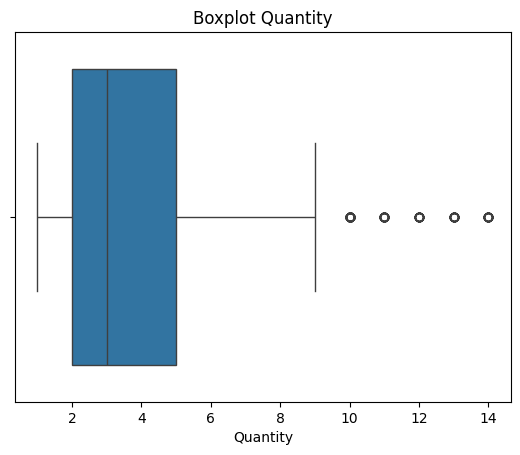

In [ ]:
sns.boxplot(x=df2["Quantity"])
plt.title("Boxplot Quantity")
plt.show()

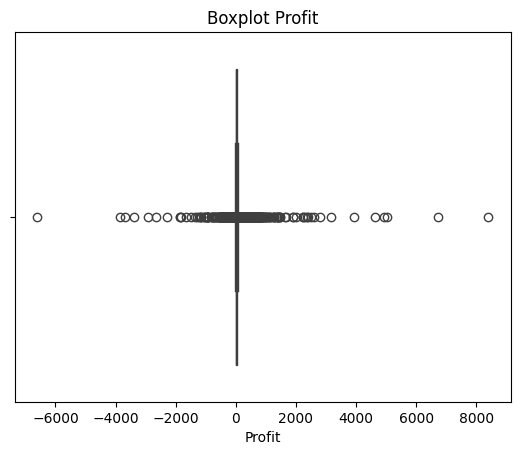

In [ ]:
sns.boxplot(x=df2["Profit"])
plt.title("Boxplot Profit")
plt.show()

In [ ]:
df2.isnull().sum()

,0
Order ID,0
Product ID,0
Sales,0
Quantity,0
Discount,0
Profit,0


In [ ]:
print(f"Total duplicated rows : {df2.duplicated().sum()}")

Total duplicated rows : 1


In [ ]:
df_numeric = df2.select_dtypes(include=['int64', 'float64'])
correlation_matrix = df_numeric.corr()

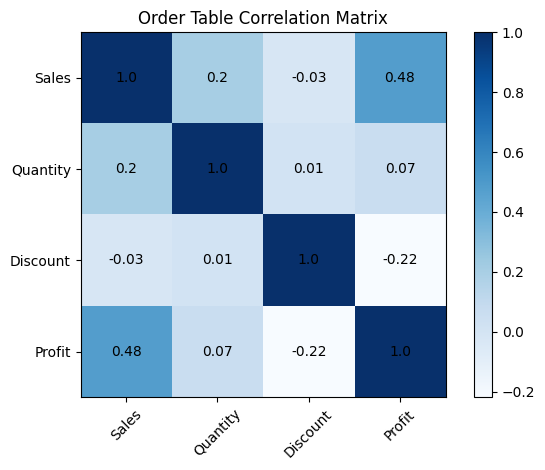

In [ ]:
plt.figure()
plt.imshow(correlation_matrix, cmap='Blues')
plt.colorbar()

plt.xticks(
    ticks=np.arange(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns
)
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            round(correlation_matrix.iloc[i, j], 2),
            ha='center',
            va='center'
        )
plt.title("Order Table Correlation Matrix")
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

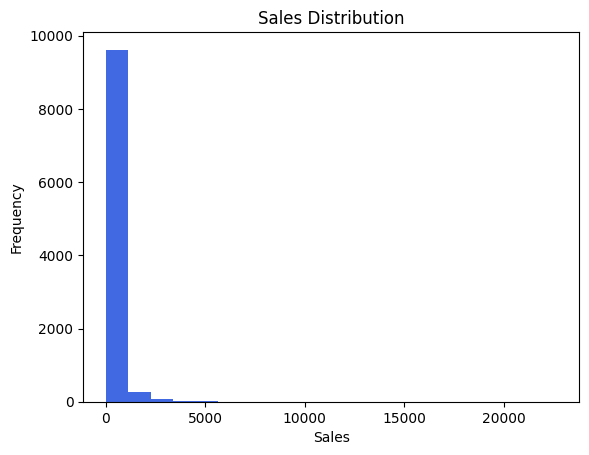

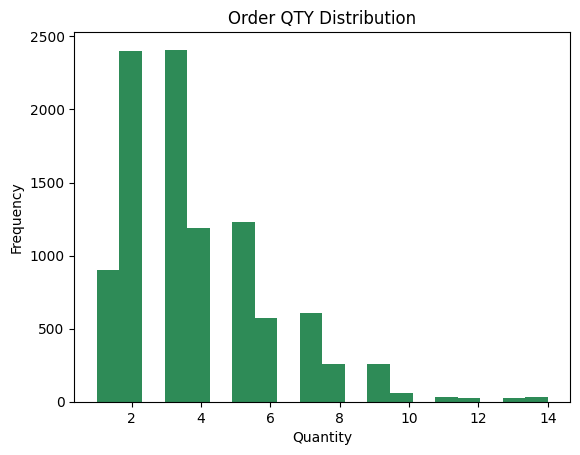

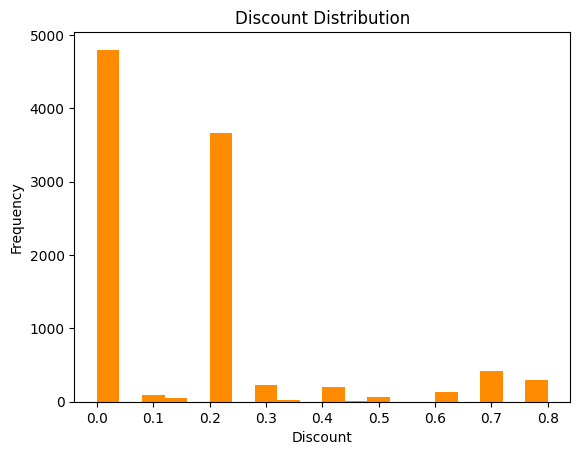

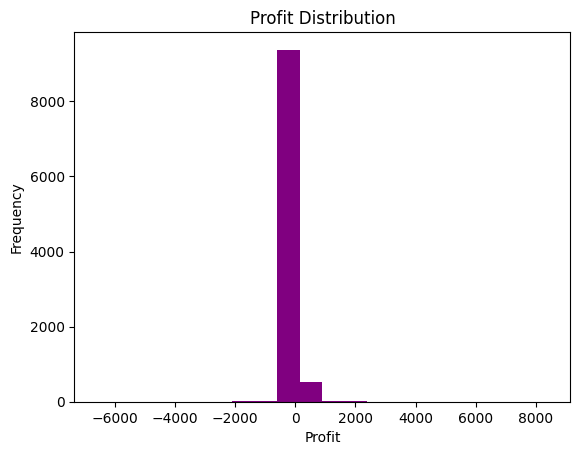

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(14,8))

plt.figure()
plt.hist(df2['Sales'], bins=20, color='royalblue')
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df2['Quantity'], bins=20, color='seagreen')
plt.title("Order QTY Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df2['Discount'], bins=20, color='darkorange')
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df2['Profit'], bins=20, color='purple')
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

plt.suptitle("Exploratory Data Analysis", fontsize=26, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Products

In [ ]:
df3

,Product ID,Category,Sub-Category,Product Name
0,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System
...,...,...,...,...
1889,TEC-PH-10002817,Technology,Phones,RCA ViSYS 25425RE1 Corded phone
1890,TEC-MA-10003589,Technology,Machines,Cisco 8961 IP Phone Charcoal
1891,OFF-AP-10003099,Office Supplies,Appliances,"Eureka Hand Vacuum, Bagless"
1892,TEC-PH-10002645,Technology,Phones,LG G2


In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1894 entries, 0 to 1893
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product ID    1894 non-null   object
 1   Category      1894 non-null   object
 2   Sub-Category  1894 non-null   object
 3   Product Name  1894 non-null   object
dtypes: object(4)
memory usage: 59.3+ KB


In [ ]:
df3.dtypes

,0
Product ID,object
Category,object
Sub-Category,object
Product Name,object


In [ ]:
df3.describe(include=object)

,Product ID,Category,Sub-Category,Product Name
count,1894,1894,1894,1894
unique,1862,3,17,1841
top,OFF-PA-10002195,Office Supplies,Paper,Staples
freq,2,1098,284,46


In [ ]:
df3.isnull().sum()

,0
Product ID,0
Category,0
Sub-Category,0
Product Name,0


In [ ]:
print(f"Total duplicated rows : {df3.duplicated().sum()}")

Total duplicated rows : 0


In [ ]:
daftar_unik = df3['Category'].unique()
print(f"Daftar nilai unik: {daftar_unik}")

Daftar nilai unik: ['Furniture' 'Office Supplies' 'Technology']


In [ ]:
daftar_unik = df3['Sub-Category'].unique()
print(f"Daftar nilai unik: {daftar_unik}")

Daftar nilai unik: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


# JOINING/Integrasi Data


In [ ]:
df_new = df1.merge(df2, how="inner", on="Order ID")
df_new

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...
9989,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,FUR-FU-10001889,25.2480,3,0.20,4.1028
9990,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,FUR-FU-10000747,91.9600,2,0.00,15.6332
9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,TEC-PH-10003645,258.5760,2,0.20,19.3932
9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,OFF-PA-10004041,29.6000,4,0.00,13.3200


# Feature Engineering

In [ ]:
df_new['order_month'] = df_new['Order Date'].dt.month
df_new['order_year'] = df_new['Order Date'].dt.year

In [ ]:
df_new['Revenue'] = df_new['Sales'] * df_new['Quantity'] * (1 - df_new['Discount'])

In [ ]:
df_fix= df_new[
    [
        'Order ID',
        'Order Date',
        'Ship Date',
        'Ship Mode',
        'Customer ID',
        'Product ID',
        'Sales',
        'Quantity',
        'Discount',
        'Profit',
        'order_month',
        'order_year',
        'Revenue'
    ]
]

In [ ]:
df_fix

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit,order_month,order_year,Revenue
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136,11,2013,523.920000
1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820,11,2013,2195.820000
2,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714,6,2013,29.240000
3,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310,10,2012,2633.338125
4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164,10,2012,35.788800
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,FUR-FU-10001889,25.2480,3,0.20,4.1028,1,2011,60.595200
9990,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,FUR-FU-10000747,91.9600,2,0.00,15.6332,2,2014,183.920000
9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,TEC-PH-10003645,258.5760,2,0.20,19.3932,2,2014,413.721600
9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,OFF-PA-10004041,29.6000,4,0.00,13.3200,2,2014,118.400000


In [ ]:
df_BNSP = df_fix.merge(df3, how="inner", on="Product ID")
df_BNSP

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Product ID,Sales,Quantity,Discount,Profit,order_month,order_year,Revenue,Category,Sub-Category,Product Name
0,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-BO-10001798,261.9600,2,0.00,41.9136,11,2013,523.920000,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,FUR-CH-10000454,731.9400,3,0.00,219.5820,11,2013,2195.820000,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,OFF-LA-10000240,14.6200,2,0.00,6.8714,6,2013,29.240000,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,FUR-TA-10000577,957.5775,5,0.45,-383.0310,10,2012,2633.338125,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,OFF-ST-10000760,22.3680,2,0.20,2.5164,10,2012,35.788800,Office Supplies,Storage,Eldon Fold 'N Roll Cart System
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10326,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,FUR-FU-10001889,25.2480,3,0.20,4.1028,1,2011,60.595200,Furniture,Furnishings,Ultra Door Pull Handle
10327,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,FUR-FU-10000747,91.9600,2,0.00,15.6332,2,2014,183.920000,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...
10328,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,TEC-PH-10003645,258.5760,2,0.20,19.3932,2,2014,413.721600,Technology,Phones,Aastra 57i VoIP phone
10329,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,OFF-PA-10004041,29.6000,4,0.00,13.3200,2,2014,118.400000,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5"""


In [ ]:
df_BNSP.to_excel('/content/drive/MyDrive/New/BNSP.xlsx', index=False)